In [8]:
import pandas as pd
import numpy as np
import scorecardpy as sc
from sklearn.model_selection import train_test_split
import pickle

In [3]:
df = pd.read_csv('../data/processed/loan_data_stage_2.csv')

features = [
    'target',             
    'loan_amnt',         
    'term_int',           
    'int_rate',          
    'annual_inc',        
    'emp_length_int',   
    'home_ownership',    
    'dti',                
    'delinq_2yrs',        
    'inq_last_6mths',    
    'revol_util',        
    'total_acc',          
    'months_since_earliest_cr_line', 
    'purpose'             #
]

df_final = df[features].copy()
print(df_final.isnull().sum())

target                             0
loan_amnt                          0
term_int                           0
int_rate                           0
annual_inc                         0
emp_length_int                     0
home_ownership                     0
dti                                0
delinq_2yrs                       29
inq_last_6mths                    29
revol_util                       231
total_acc                         29
months_since_earliest_cr_line     29
purpose                            0
dtype: int64


In [4]:
cols_to_fix = ['delinq_2yrs', 'inq_last_6mths', 'revol_util', 'total_acc', 'months_since_earliest_cr_line']
for col in cols_to_fix:
    df_final[col] = df_final[col].fillna(df_final[col].median())

In [5]:
train, test = train_test_split(df_final, test_size=0.3, random_state=42, stratify=df_final['target'])
print(f"Размер train выборки: {train.shape}")
print(f"Размер test выборки: {test.shape}")

Размер train выборки: (166386, 14)
Размер test выборки: (71309, 14)


# Расчет WOE and IV

In [6]:
bins = sc.woebin(train, y='target')
iv_list = []
for col in bins:
    iv_list.append({'feature': col, 'iv': bins[col]['total_iv'].iloc[0]})

iv_df = pd.DataFrame(iv_list).sort_values(by='iv', ascending=False)
print(iv_df)

[INFO] creating woe binning ...


c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed

Binning on 166386 rows and 14 columns in 00:00:22
                          feature        iv
11                       int_rate  0.387292
0                        term_int  0.161274
2                             dti  0.087733
9                      revol_util  0.060531
3                      annual_inc  0.048562
6                       loan_amnt  0.031178
10                        purpose  0.020415
8                  inq_last_6mths  0.016563
7                  home_ownership  0.014320
5                  emp_length_int  0.005295
12                      total_acc  0.003830
1                     delinq_2yrs  0.003295
4   months_since_earliest_cr_line  0.002778


c:\Users\Admin\credit-scoring-project\venv\lib\site-packages\scorecardpy\woebin.py:1304: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bins = bins.groupby('variable', group_keys=False).apply(gb_distr)


{'int_rate': <Figure size 640x480 with 2 Axes>}

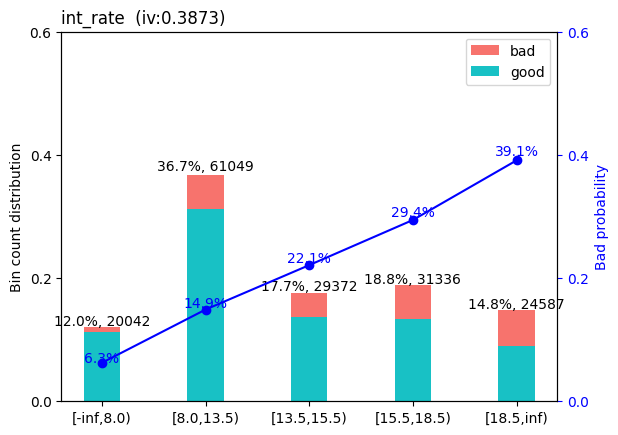

In [7]:
sc.woebin_plot(bins['int_rate'])

Видим что вероятность дефолта растет монотонной зависимостью. То есть чем выше риск дефолта тем выше банк задирает ставку. Насчет рейтинга IV, мы видим что лидеры это int_rate, term_int, то есть длинные и дорогие кредиты часто уходят в дефолт. Средне значимые колонки это dti, revol_util, annual_inс, долговая нагрузка важнее чем просто сумма дохода. 

Мусор: delinq_2yrs, total_acc, months_since_earliest_cr_line, потому что у них IV < 0.02. Интересно то, что просрочки в прошлом (delinq_2yrs) в этом датасете почти не помогают предсказать будущее.

In [9]:
with open('../data/processed/bins.pkl', 'wb') as f:
    pickle.dump(bins, f)

In [10]:
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)
train_woe.to_csv('../data/processed/train_woe.csv', index=False)
test_woe.to_csv('../data/processed/test_woe.csv', index=False)

[INFO] converting into woe values ...
[INFO] converting into woe values ...
